In [9]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## adding sorted id by predictedd price

### GWR

In [2]:
gwr_table = pd.read_csv('../database/gwr_predicted.csv')

In [4]:
gwr_table['SortedID'] = gwr_table['PREDICTED'].rank(method='dense')


In [6]:
gwr_table.sort_values('PREDICTED')

,OID_,SOURCE_ID,price,square_meters,INTRCPT,SE_INTRCPT,T_INTRCPT,SG_INTRCPT,C_SQUARE_METERS,SE_SQUARE_METERS,...,SG_SQUARE_METERS,PREDICTED,SortedID,RESIDUAL,STDRESID,INFLUENCE,COOKS_D,CND_NUMBER,LOCALR2,NUM_NEIGHS
356,357,357,24000.000000,49.0,-11820.113655,39419.572689,-0.299854,0,530.923788,397.816481,...,0,14195.151934,1.0,9804.848066,0.301003,0.411059,2.797518e-05,323.334882,-0.337686,157
49,50,50,10000.000000,42.0,-6902.642702,24849.072068,-0.277783,0,648.752055,319.817643,...,0,20344.943617,2.0,-10344.943617,-0.256295,0.095709,3.075540e-06,224.458005,0.359752,157
45,46,46,22000.000000,100.0,161992.283218,83079.120706,1.949856,0,-1398.564951,1249.382371,...,0,22135.788160,3.0,-135.788160,-0.068468,0.997817,9.478608e-04,177217.073132,0.941051,157
928,929,929,29361.389772,46.0,-6902.013373,24850.776986,-0.277738,0,648.770659,319.837349,...,0,22941.436961,4.0,6419.952811,0.157592,0.078853,9.404891e-07,224.436826,0.359830,157
23098,23099,23099,50000.000000,40.0,-70333.999371,15848.759124,-4.437824,1,2358.919905,181.869422,...,1,24022.796812,5.0,25977.203188,0.635606,0.072869,1.404667e-05,140.097510,0.523382,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31267,31268,31268,695000.000000,460.0,23339.289903,9583.762860,2.435295,0,1213.599091,46.825897,...,1,581594.871902,52454.0,113405.128098,2.953033,0.181421,8.549926e-04,109.195009,0.845697,157
22740,22741,22741,570000.000000,460.0,22676.019920,9661.819375,2.346972,0,1218.668486,47.220874,...,1,583263.523552,52455.0,-13263.523552,-0.345741,0.183138,1.185578e-05,109.680230,0.847218,157
49786,49787,49787,520000.000000,165.0,-14727.774423,16411.036174,-0.897431,0,3756.557730,156.750456,...,1,605104.250945,52456.0,-85104.250945,-2.071672,0.063317,1.283429e-04,176.986039,0.535824,157
49787,49788,49788,520000.000000,165.0,-15007.825700,16411.025034,-0.914497,0,3758.773049,156.751567,...,1,605189.727394,52457.0,-85189.727394,-2.073740,0.063306,1.285739e-04,176.879914,0.536001,157


In [ ]:
gwr_table.to_csv('../database/predicted_data//gwr_predicted.csv')

### GLR

In [13]:
glr_table = pd.read_csv('../database/predicted_data/glr_predicted.csv')

In [14]:
glr_table['SortedID'] = glr_table['PREDICTED'].rank(method='dense')

In [16]:
glr_table.sort_values('PREDICTED')

,SOURCE_ID,price,square_met,PREDICTED,RESIDUAL,STDRESID,SortedID
26091,10262,39000.0,40.0,7892.251280,31107.748720,0.478613,1.0
25977,2127,30000.0,40.0,7892.251280,22107.748720,0.340142,1.0
40584,35243,69500.0,41.0,9870.029539,59629.970460,0.701809,2.0
26266,37719,75000.0,41.0,10594.563530,64405.436470,0.990920,3.0
40574,22721,52000.0,42.0,12858.784290,39141.215710,0.460668,4.0
...,...,...,...,...,...,...,...
48342,6663,450000.0,500.0,453640.676600,-3640.676625,-0.045106,4183.0
48406,25282,680000.0,520.0,468896.551900,211103.448100,2.615449,4184.0
48318,358,295000.0,600.0,529920.053200,-234920.053200,-2.910523,4185.0
48308,55,145000.0,600.0,529920.053200,-384920.053200,-4.768936,4185.0


In [19]:
glr_table.to_csv('../database/predicted_data/glr_predicted.csv')

## Performance Metrics

In [2]:
# Load the CSV files
glr_df = pd.read_csv("../database/predicted_data/glr_predicted.csv")
gwr_df = pd.read_csv("../database/predicted_data/gwr_predicted.csv")
fbcr_df = pd.read_csv("../database/predicted_data/fbcr_predicted.csv")

In [6]:
# Calculate the performance metrics for each model
glr_mae = mean_absolute_error(glr_df["price"], glr_df["PREDICTED"])
glr_rmse = mean_squared_error(glr_df["price"], glr_df["PREDICTED"], squared=False)
glr_r2 = r2_score(glr_df["price"], glr_df["PREDICTED"])

gwr_mae = mean_absolute_error(gwr_df["price"], gwr_df["PREDICTED"])
gwr_rmse = mean_squared_error(gwr_df["price"], gwr_df["PREDICTED"], squared=False)
gwr_r2 = r2_score(gwr_df["price"], gwr_df["PREDICTED"])

fbcr_mae = mean_absolute_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"])
fbcr_rmse = mean_squared_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"], squared=False)
fbcr_r2 = r2_score(fbcr_df["PRICE"], fbcr_df["PREDICTED"])

# Print the results
print("GLR: MAE={}, RMSE={}, R2={}".format(glr_mae, glr_rmse, glr_r2))
print("GWR: MAE={}, RMSE={}, R2={}".format(gwr_mae, gwr_rmse, gwr_r2))
print("FBCR: MAE={}, RMSE={}, R2={}".format(fbcr_mae, fbcr_rmse, fbcr_r2))

GLR: MAE=34715.93918731483, RMSE=52320.61547723658, R2=0.5819770279231573
GWR: MAE=27032.122071295522, RMSE=41258.582087686635, R2=0.7400540486294145
FBCR: MAE=14053.22613003116, RMSE=22733.53833832878, R2=0.9192043740691891


## Scatterplots price vs predicted

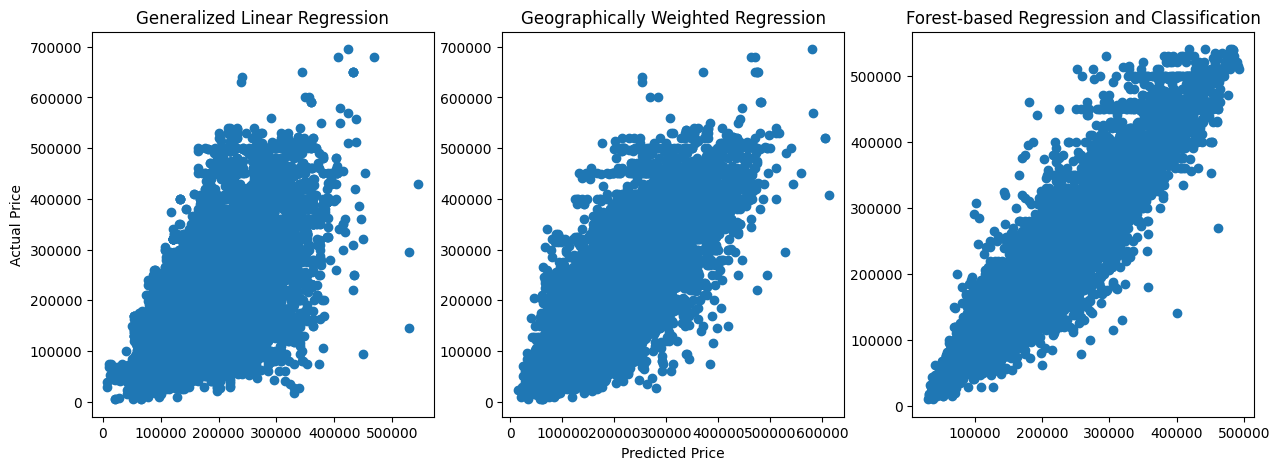

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
axs[0].scatter(glr_df["PREDICTED"], glr_df["price"])
axs[0].set_title("Generalized Linear Regression")
# axs[0].set_xlabel("Predicted Price")
axs[0].set_ylabel("Actual Price")

# Geographically Weighted Regression model
axs[1].scatter(gwr_df["PREDICTED"], gwr_df["price"])
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Predicted Price")
# axs[1].set_ylabel("Actual Price")

# Forest-based Regression and Classification model
axs[2].scatter(fbcr_df["PREDICTED"], fbcr_df["PRICE"])
axs[2].set_title("Forest-based Regression and Classification")
# axs[2].set_xlabel("Predicted Price")
# axs[2].set_ylabel("Actual Price")

plt.show()

## Distribution measurement

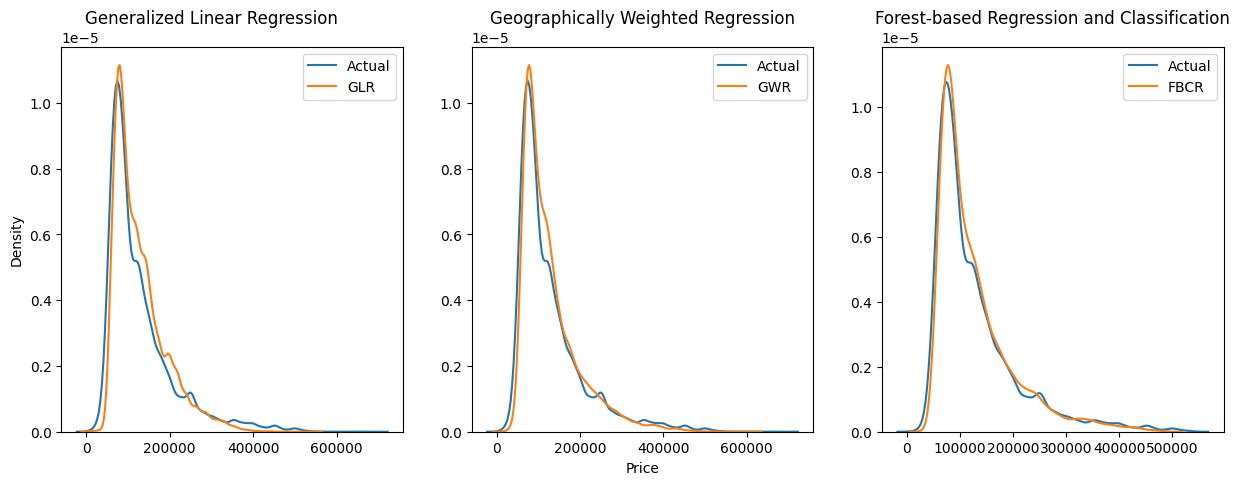

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
sns.kdeplot(data=glr_df, x="price", label="Actual", ax=axs[0], legend=True)
sns.kdeplot(data=glr_df, x="PREDICTED", label="GLR", ax=axs[0], legend=True)
axs[0].set_title("Generalized Linear Regression        ")
axs[0].set_xlabel('')
axs[0].legend()

# Geographically Weighted Regression model
sns.kdeplot(data=gwr_df, x="price", label="Actual", ax=axs[1], legend=True)
sns.kdeplot(data=gwr_df, x="PREDICTED", label="GWR", ax=axs[1], legend=True)
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Price")
axs[1].set_ylabel('')
axs[1].legend()

# Forest-based Regression and Classification model
sns.kdeplot(data=fbcr_df, x="PRICE", label="Actual", ax=axs[2], legend=True)
sns.kdeplot(data=fbcr_df, x="PREDICTED", label="FBCR", ax=axs[2], legend=True)
axs[2].set_title("Forest-based Regression and Classification")
axs[2].set_xlabel("")
axs[2].set_ylabel('')
axs[2].legend()

# Display the plots
plt.show()

### Model comparison

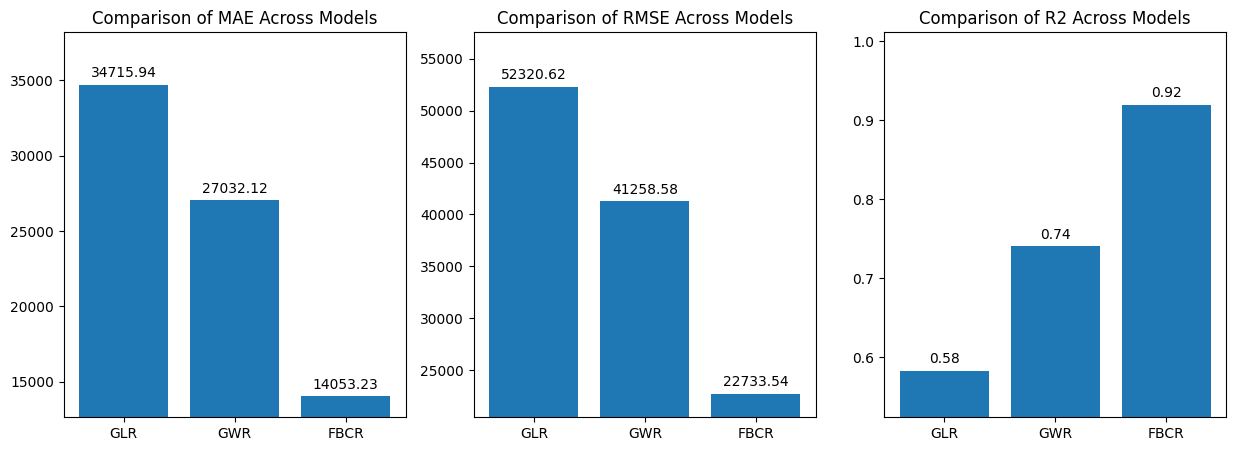

In [46]:
# Define the metrics for each model as a dictionary
metrics = {
    "GLR": [glr_mae, glr_rmse, glr_r2],
    "GWR": [gwr_mae, gwr_rmse, gwr_r2],
    "FBCR": [fbcr_mae, fbcr_rmse, fbcr_r2]
}

# Define the names of the metrics to be plotted
metric_names = ["MAE", "RMSE", "R2"]

# Create a grid of plots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Loop through each metric and create a bar plot for each model
for i, metric in enumerate(metric_names):
    values = [metrics[model][i] for model in metrics.keys()]
    axs[i].bar(metrics.keys(), values)
    axs[i].set_xlabel("Model")
    axs[i].set_ylabel(metric)
    axs[i].set_title("Comparison of {} Across Models".format(metric))
    axs[i].set_ylim([min(values) * 0.9, max(values) * 1.1])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    for j, v in enumerate(values):
        if metric == "R2":
            axs[i].text(j, v + 0.01, str(round(v, 2)), ha='center')
        elif metric == "MAE":
            axs[i].text(j, v + 500, str(round(v, 2)), ha='center')
        else:
            axs[i].text(j, v + 750, str(round(v, 2)), ha='center')
        # axs[i].text(j, v + 0.01, str(round(v, 2)), ha='center')
    # axs[i].grid(axis='y')
    

# Display the plots

plt.show()